# Question 4
- There was 4 iterations in total, first we started with a simple embedding layer, then we moved to BERT.
- Bhavik suggested us to decrease the dataset size, which we did an narrowed down to drinks from 96k samples to 7.6k samples.
- We tried increasing UNET, clipping gradients and still got the same issue.

Prompt:
I need to create a Text to Image diffusion Model like GLIDE using the labels on YELP dataset.

- I already have a script to load the images with tensorflow, augment I need one to run the diffusor model with the labels, preferably Stable Diffusion
- Generate a A TensorFlow-compatible UNet (for diffusion), A noise scheduler like DDPM and a  simple tokenizer + text embedding block
- Also help me with the train loop, I want to generate sample images and log visualizations as I will leave it running

We will do step by step ask me when you need to go to the next step.

OpenAI. (2025). Training a DCGAN [ChatGPT response]. OpenAI. Retrieved March 29, 2025, from https://chat.openai.com

In [1]:
import json
import os
import tensorflow as tf
import pandas as pd
from pathlib import Path
from scipy.linalg import sqrtm
from scipy.stats import entropy
import numpy as np
import shutil

#tf.keras.mixed_precision.set_global_policy('mixed_float16')

PHOTOS_DIR = 'data/photos'
JSON_PATH = 'data/photos.json'

df_photos = pd.read_json('data/clean_photos.json', lines=True)

SOURCE_DIR = Path("data/photos")
DEST_DIR = Path("data/drinks")

# Enable dynamic GPU memory growth
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)


2025-04-01 12:14:48.888473: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-01 12:14:49.325765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743524089.459583    1238 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743524089.487585    1238 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743524089.847750    1238 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

### Filtering only not null captions

In [2]:
import pandas as pd
import os
import re

def clean_caption(text):
    text = str(text).strip()
    text = re.sub(r"<.*?>", "", text)               # Remove
    text = re.sub(r"\s+", " ", text)                # Normal
    text = re.sub(r"[^a-zA-Z0-9\s.,!?\"'()\-:]", "", text)  
    return text

def filter_and_clean_captions(df, image_dir):

    # Drop rows with missing or empty captions
    df = df[df['caption'].notnull()]
    df = df[df['caption'].str.strip() != ""]

    # Clean captions
    df['caption'] = df['caption'].apply(clean_caption)

    # Drop entries where image is missing
    df['image_path'] = df['photo_id'].apply(lambda pid: os.path.join(image_dir, f"{pid}.jpg"))
    df = df[df['image_path'].apply(os.path.exists)]

    return df[['image_path', 'caption']]


In [3]:
def is_valid_caption(caption):
    caption = caption.strip()
    # Remove if too short
    if len(caption) < 4:
        return False
    # Remove if just digits or a single letter
    if re.fullmatch(r"[a-zA-Z]|\d+", caption):
        return False
    return True

df_photos = df_photos[df_photos['caption'].apply(is_valid_caption)]

In [4]:
import tensorflow as tf
import pandas as pd

# Config
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3
BATCH_SIZE = 4
BUFFER_SIZE = 10000

# Pre-check image validity by attempting to decode
def is_image_valid(path, caption):
    image_bytes = tf.io.read_file(path)
    try:
        _ = tf.image.decode_jpeg(image_bytes, channels=3)
        return True
    except:
        return False

# TF-safe wrapper using tf.py_function
def tf_is_image_valid(path, caption):
    is_valid = tf.py_function(
        func=is_image_valid,
        inp=[path, caption],
        Tout=tf.bool
    )
    return is_valid

def preprocess_image(path):
    image_bytes = tf.io.read_file(path)

    try:
        image = tf.image.decode_jpeg(image_bytes, channels=3, try_recover_truncated=True)
    except:
        image = tf.zeros([IMG_HEIGHT, IMG_WIDTH, CHANNELS], dtype=tf.uint8)

    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32)
    return (image / 127.5) - 1.0


def augment_image(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    return image

def preprocess_pair(path, caption, augment=True):
    image = preprocess_image(path)
    if augment:
        image = augment_image(image)
    return image, caption

def load_caption_dataset(json_path, augment=True):
    df = pd.read_json(json_path, lines=True)
    image_paths = df['image_path'].astype(str).tolist()
    captions = df['caption'].astype(str).tolist()

    ds = tf.data.Dataset.from_tensor_slices((image_paths, captions))

    # FILTER OUT BROKEN FILES FIRST
    ds = ds.filter(tf_is_image_valid)

    preprocess_fn = lambda path, cap: preprocess_pair(path, cap, augment)
    ds = ds.map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Instantiate dataset
train_dataset = load_caption_dataset("data/clean_photos.json")


I0000 00:00:1743524099.947464    1238 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9511 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
#class SimpleTextEncoder(tf.keras.Model):
#    def __init__(self, vocab_size=1000, embed_dim=128, rnn_units=256):
#        super().__init__()
#        self.embedding = tf.keras.layers.Embedding(vocab_size, embed_dim)
#        self.rnn = tf.keras.layers.GRU(rnn_units, return_sequences=False)
#
#    def call(self, input_ids):
#        x = self.embedding(input_ids)
#        return self.rnn(x)
    
from transformers import TFAutoModel, AutoTokenizer

# Load DistilBERT (or MiniLM, TinyBERT, etc.)
bert = TFAutoModel.from_pretrained("distilbert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def encode_prompt_bert(prompt_tensor):
    # Convert Tensor to list of Python strings
    prompt_list = prompt_tensor.numpy().astype(str).tolist()
    
    # Now use tokenizer
    inputs = tokenizer(prompt_list, return_tensors="tf", padding=True, truncation=True)
    outputs = bert(**inputs)
    return outputs.last_hidden_state[:, 0, :]  # CLS token



/home/leandro-sartini/miniconda3/envs/work/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertFor

In [6]:
import tensorflow as tf

class ResBlock(tf.keras.layers.Layer):
    def __init__(self, channels, time_dim, text_dim):
        super().__init__()
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.act1 = tf.keras.layers.Activation("swish")
        self.conv1 = tf.keras.layers.Conv2D(channels, 3, padding="same")

        self.norm2 = tf.keras.layers.LayerNormalization()
        self.act2 = tf.keras.layers.Activation("swish")
        self.conv2 = tf.keras.layers.Conv2D(channels, 3, padding="same")

        self.time_mlp = tf.keras.layers.Dense(channels)
        self.text_mlp = tf.keras.layers.Dense(channels)
        self.residual_conv = None
        self.channels = channels

    def build(self, input_shape):
        in_channels = input_shape[-1]
        if in_channels != self.channels:
            self.residual_conv = tf.keras.layers.Conv2D(self.channels, 1)

    def call(self, x, t_emb, txt_emb):
        h = self.conv1(self.act1(self.norm1(x)))
        h += self.time_mlp(t_emb)[:, None, None, :]
        h += self.text_mlp(txt_emb)[:, None, None, :]
        h = self.conv2(self.act2(self.norm2(h)))
        if self.residual_conv:
            x = self.residual_conv(x)
        return x + h

class DownBlock(tf.keras.layers.Layer):
    def __init__(self, in_channels, out_channels, time_dim, text_dim):
        super().__init__()
        self.resblock1 = ResBlock(in_channels, time_dim, text_dim)
        self.resblock2 = ResBlock(out_channels, time_dim, text_dim)
        self.down = tf.keras.layers.Conv2D(out_channels, 4, strides=2, padding="same")

    def call(self, x, t_emb, txt_emb):
        x = self.resblock1(x, t_emb, txt_emb)
        x = self.down(x)
        x = self.resblock2(x, t_emb, txt_emb)
        return x

class UpBlock(tf.keras.layers.Layer):
    def __init__(self, in_channels, out_channels, time_dim, text_dim):
        super().__init__()
        self.resblock1 = ResBlock(in_channels, time_dim, text_dim)
        self.resblock2 = ResBlock(out_channels, time_dim, text_dim)
        self.upsample = tf.keras.layers.UpSampling2D(size=2)

    def call(self, x, skip, t_emb, txt_emb):
        x = self.upsample(x)
        x = tf.concat([x, skip], axis=-1)
        x = self.resblock1(x, t_emb, txt_emb)
        x = self.resblock2(x, t_emb, txt_emb)
        return x

class UNet(tf.keras.Model):
    def __init__(self, base_channels=64, time_emb_dim=256, text_emb_dim=256):
        super().__init__()
        self.time_mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(time_emb_dim, activation="swish"),
            tf.keras.layers.Dense(time_emb_dim)
        ])

        self.init_conv = tf.keras.layers.Conv2D(base_channels, 3, padding="same")

        self.down1 = DownBlock(base_channels, base_channels * 2, time_emb_dim, text_emb_dim)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4, time_emb_dim, text_emb_dim)

        self.middle = ResBlock(base_channels * 4, time_emb_dim, text_emb_dim)

        self.up1 = UpBlock(base_channels * 4 + base_channels * 2, base_channels * 2, time_emb_dim, text_emb_dim)
        self.up2 = UpBlock(base_channels * 2 + base_channels, base_channels, time_emb_dim, text_emb_dim)

        self.final_conv = tf.keras.layers.Conv2D(3, 1)

    def call(self, x, t, txt_emb):
        t = tf.cast(t, tf.float32)
        t = tf.expand_dims(t, axis=-1)
        t_emb = self.time_mlp(t)

        x1 = self.init_conv(x)
        x2 = self.down1(x1, t_emb, txt_emb)
        x3 = self.down2(x2, t_emb, txt_emb)

        x4 = self.middle(x3, t_emb, txt_emb)

        x5 = self.up1(x4, x2, t_emb, txt_emb)
        x6 = self.up2(x5, x1, t_emb, txt_emb)

        return self.final_conv(x6)

In [7]:
class DDPMNoiseScheduler:
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02):
        self.timesteps = timesteps
        self.betas = np.linspace(beta_start, beta_end, timesteps, dtype=np.float32)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = np.cumprod(self.alphas)

    def add_noise(self, x0, t, noise):
        """
        x0: original image (B, H, W, C)
        t: timestep indices (B,)
        noise: noise to add (B, H, W, C)
        """
        alpha_bar_t = tf.gather(self.alpha_bars, t)
        alpha_bar_t = tf.reshape(alpha_bar_t, [-1, 1, 1, 1])

        return tf.sqrt(alpha_bar_t) * x0 + tf.sqrt(1 - alpha_bar_t) * noise


In [8]:
import os
from datetime import datetime
import matplotlib.pyplot as plt

# Paths
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = f"runs/{run_id}"
os.makedirs(log_dir + "/samples", exist_ok=True)
checkpoint_dir = f"{log_dir}/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# TensorBoard writer
summary_writer = tf.summary.create_file_writer(log_dir)

In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from datetime import datetime

# Optional: Projection layer for BERT -> UNet dim
bert_proj = tf.keras.layers.Dense(256)

# BERT-based prompt embedding function (already defined earlier)
@tf.function
def get_bert_embeddings_tf(prompts):
    output = tf.py_function(encode_prompt_bert, [prompts], tf.float32)
    output.set_shape([None, 768])  # BERT's CLS embedding shape
    return bert_proj(output)       # Now it's safe to pass to Dense

def save_sample_image(unet, scheduler, save_path, image_size=128, timesteps=1000):
    prompts = df_photos["caption"].dropna().sample(5).tolist()
    batch_size = len(prompts)

    # Ensure float32 BERT output and projection
    text_emb = get_bert_embeddings_tf(tf.constant(prompts))

    # Start from noise
    x = tf.random.normal([batch_size, image_size, image_size, 3], dtype=tf.float32)

    for t in reversed(range(timesteps)):
        t_tensor = tf.fill([batch_size], t)

        pred_noise = unet(x, t_tensor, text_emb)

        alpha = tf.convert_to_tensor(scheduler.alphas[t], dtype=tf.float32)
        alpha_bar = tf.convert_to_tensor(scheduler.alpha_bars[t], dtype=tf.float32)
        alpha_bar_prev = tf.convert_to_tensor(
            scheduler.alpha_bars[t - 1] if t > 0 else 1.0, dtype=tf.float32
        )
        beta = tf.convert_to_tensor(1.0 - alpha / alpha_bar_prev, dtype=tf.float32)

        noise = tf.random.normal(x.shape, dtype=tf.float32) if t > 0 else tf.constant(0.0, dtype=tf.float32)

        x = (1.0 / tf.sqrt(alpha)) * (
            x - ((1.0 - alpha) / tf.sqrt(1.0 - alpha_bar)) * pred_noise
        ) + tf.sqrt(beta) * noise

    preds = tf.clip_by_value((x + 1.0) / 2.0, 0.0, 1.0)

    # Plot and save
    fig, axs = plt.subplots(1, batch_size, figsize=(batch_size * 2, 2))
    for i, img in enumerate(preds):
        axs[i].imshow(img.numpy())
        axs[i].set_title(prompts[i][:30], fontsize=6)
        axs[i].axis("off")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()


# Training loop (no FID computation)
def train_diffusion_model(
    dataset,
    unet,
    noise_scheduler,
    epochs=10,
    lr=1e-4,
    batch_size=8,
    timesteps=1000,
    log_dir="runs"
):
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    mse = tf.keras.losses.MeanSquaredError()
    global_step = 0

    run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
    tb_dir = os.path.join(log_dir, run_id)
    ckpt_dir = os.path.join(tb_dir, "checkpoints")
    sample_dir = os.path.join(tb_dir, "samples")

    os.makedirs(ckpt_dir, exist_ok=True)
    os.makedirs(sample_dir, exist_ok=True)

    summary_writer = tf.summary.create_file_writer(tb_dir)
    steps_per_epoch = 7600 // batch_size

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        progress = tqdm(dataset, total=steps_per_epoch, desc=f"Epoch {epoch+1}", unit="batch")

        for step, (images, prompts) in enumerate(progress):
            batch_size = tf.shape(images)[0]
            t = tf.random.uniform((batch_size,), minval=0, maxval=timesteps, dtype=tf.int32)
            noise = tf.random.normal(shape=tf.shape(images))

            text_embeddings = get_bert_embeddings_tf(tf.reshape(prompts, [-1]))
            noisy_images = noise_scheduler.add_noise(images, t, noise)

            with tf.GradientTape() as tape:
                pred_noise = unet(noisy_images, t, text_embeddings)
                loss = mse(noise, pred_noise)

            grads = tape.gradient(loss, unet.trainable_variables)
            optimizer.apply_gradients(zip(grads, unet.trainable_variables))

            with summary_writer.as_default():
                tf.summary.scalar("loss", loss, step=global_step)

            progress.set_postfix(loss=loss.numpy())

            if step % 500 == 0:
                sample_path = os.path.join(sample_dir, f"epoch{epoch}_step{step}.png")
                save_sample_image(unet, scheduler, save_path=sample_path)

            global_step += 1

        unet.save_weights(os.path.join(ckpt_dir, f"unet_epoch{epoch}.weights.h5"))


In [10]:
captions = df_photos["caption"].astype(str).tolist()

In [11]:
unet = UNet(base_channels=128, time_emb_dim=256, text_emb_dim=256)
scheduler = DDPMNoiseScheduler()

In [ ]:
unet = UNet(base_channels=128, time_emb_dim=256, text_emb_dim=256)
scheduler = DDPMNoiseScheduler()

train_diffusion_model(
    train_dataset,
    unet=unet,
    noise_scheduler=scheduler,
    epochs=10,
    lr=1e-4
)




Epoch 1/10


Epoch 1:   0%|                                                                               | 0/950 [00:00<?, ?batch/s]2025-03-31 20:24:28.103755: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2236 of 10000
2025-03-31 20:24:48.103444: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 6882 of 10000
2025-03-31 20:24:50.930430: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.
I0000 00:00:1743467091.570149   14931 cuda_dnn.cc:529] Loaded cuDNN version 90800
I0000 00:00:1743467095.201333   14931 service.cc:152] XLA service 0x42c00150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743467095.201367   14931 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2025-03-31 20:24:55.207972: I tensorflow

Epoch 1: 1878batch [22:13,  1.38batch/s, loss=0.0264]                                                                   2025-03-31 20:46:31.335530: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Epoch 1: 1878batch [22:13,  1.41batch/s, loss=0.0264]



Epoch 2/10


Epoch 2:   0%|                                                                               | 0/950 [00:00<?, ?batch/s]2025-03-31 20:46:42.263722: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2097 of 10000
2025-03-31 20:46:52.266925: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 4038 of 10000
2025-03-31 20:47:02.263290: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 5991 of 10000
2025-03-31 20:47:09.820735: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.
Epoch 2: 1878batch [22:36,  2.81batch/s, loss=0.00924]                                                                  2025-03-31 21:09:08.780910: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: E

...

Epoch 4:   0%|                                                                               | 0/950 [00:00<?, ?batch/s]2025-03-31 21:31:08.187317: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2112 of 10000
2025-03-31 21:31:28.186294: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 6040 of 10000
2025-03-31 21:31:35.681514: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.
Epoch 4: 1878batch [20:31,  2.94batch/s, loss=0.0382]                                                                   2025-03-31 21:51:29.418350: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Epoch 4: 1878batch [20:31,  1.53batch/s, loss=0.0382]



Epoch 5/10


Epoch 5:   0%|                                                                               | 0/950 [00:00<?, ?batch/s]2025-03-31 21:51:40.865558: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 1637 of 10000
2025-03-31 21:52:00.865499: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 5840 of 10000
2025-03-31 21:52:08.353128: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.
Epoch 5: 1878batch [20:05,  1.56batch/s, loss=0.0273]                                                                   



Epoch 6/10


Epoch 6:   0%|                                                                               | 0/950 [00:00<?, ?batch/s]2025-03-31 22:11:46.986113: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2375 of 10000
2025-03-31 22:11:56.987895: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 4616 of 10000
2025-03-31 22:12:06.988589: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 6877 of 10000
2025-03-31 22:12:10.055237: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.
Epoch 6: 1702batch [18:57,  2.84batch/s, loss=0.0924]                                                                   

In [14]:
_ = unet(tf.zeros([1, 128, 128, 3]), tf.constant([0]), tf.zeros([1, 256]))

In [15]:
unet.load_weights("runs/20250331-202418/checkpoints/unet_epoch4.weights.h5")

In [11]:
def sample_from_model(prompt, unet, scheduler, steps=1000, image_size=128):
    # Embed prompt
    def encode_prompt_bert(prompt_text):
        inputs = tokenizer([prompt_text], return_tensors="tf", padding=True, truncation=True)
        outputs = bert(**inputs)
        return outputs.last_hidden_state[:, 0, :]  # CLS embedding

    text_emb = get_bert_embeddings_tf(tf.constant([prompt]))
    x = tf.random.normal([1, image_size, image_size, 3])
    eps = 1e-5

    for t in reversed(range(steps)):
        t_tensor = tf.constant([t], dtype=tf.int32)

        pred_noise = unet(x, t_tensor, text_emb)

        # Debug nan early
        tf.debugging.check_numerics(pred_noise, message="pred_noise contains NaN")
        tf.debugging.check_numerics(x, message="x contains NaN")

        alpha = tf.convert_to_tensor(scheduler.alphas[t], dtype=tf.float32)
        alpha_bar = tf.convert_to_tensor(scheduler.alpha_bars[t], dtype=tf.float32)
        alpha_bar_prev = tf.convert_to_tensor(scheduler.alpha_bars[t - 1] if t > 0 else 1.0, dtype=tf.float32)
        beta = tf.convert_to_tensor(1.0 - alpha / alpha_bar_prev, dtype=tf.float32)

        noise = tf.random.normal(shape=x.shape) if t > 0 else 0.0

        # Stable update step
        x = (1.0 / tf.sqrt(alpha + eps)) * (
            x - (1 - alpha) / tf.sqrt(1 - alpha_bar + eps) * pred_noise
        ) + tf.sqrt(beta + eps) * noise

    # Final clip and return
    result = tf.clip_by_value((x + 1.0) / 2.0, 0.0, 1.0)[0]
    tf.debugging.check_numerics(result, message="Final result has NaNs")
    return result


In [23]:
sample_from_model('oyster shooter',unet,scheduler)

<tf.Tensor: shape=(128, 128, 3), dtype=float32, numpy=
array([[[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        ...,
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        ...,
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        ...,
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       ...,

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        ...,
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        ...,
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        ...,
        [nan, nan, 

In [17]:
unet(tf.zeros([1, 128, 128, 3]), tf.constant([0]), tf.zeros([1, 256]))

<tf.Tensor: shape=(1, 128, 128, 3), dtype=float32, numpy=
array([[[[1.195902  , 1.0239251 , 0.44483975],
         [1.0101699 , 0.16171679, 0.65256304],
         [0.9805999 , 0.16737092, 0.722414  ],
         ...,
         [1.0826983 , 0.30202383, 0.75286055],
         [0.9380218 , 0.20673108, 0.47919205],
         [0.95617646, 0.06982868, 0.07103749]],

        [[0.39177388, 0.9285082 , 0.19209333],
         [0.31021255, 0.4424043 , 0.5085596 ],
         [0.5084073 , 0.48804688, 0.72122264],
         ...,
         [0.5391514 , 0.5123886 , 0.6956801 ],
         [0.46943912, 0.4654208 , 0.5279794 ],
         [0.7448954 , 0.20192716, 0.12559435]],

        [[0.73704296, 0.90884525, 0.4356239 ],
         [0.608667  , 0.22500852, 0.77747047],
         [0.70769304, 0.3319116 , 1.1902068 ],
         ...,
         [0.69622386, 0.3502672 , 1.1848178 ],
         [0.67255074, 0.2841832 , 0.8564518 ],
         [0.8611629 , 0.08342404, 0.40604538]],

        ...,

        [[0.5212955 , 0.8003878 , 

In [18]:
prompt = "oyster shooter"

# 1. Get BERT CLS embedding
inputs = tokenizer([prompt], return_tensors="tf", padding=True, truncation=True)
bert_output = bert(**inputs).last_hidden_state[:, 0, :]  # CLS token

print("BERT output shape:", bert_output.shape)
print("NaNs in BERT output:", tf.math.reduce_any(tf.math.is_nan(bert_output)).numpy())

# 2. Project it (make sure bert_proj was rebuilt or loaded with weights)
bert_proj = tf.keras.layers.Dense(256)
bert_proj.build((None, 768))  # manually build layer for weight loading
# OPTIONAL: load weights
# bert_proj.set_weights(np.load("runs/your_run/bert_proj_weights.npy", allow_pickle=True))

text_emb = bert_proj(bert_output)

print("Projected embedding shape:", text_emb.shape)
print("NaNs in projected:", tf.math.reduce_any(tf.math.is_nan(text_emb)).numpy())
print("text_emb preview:", text_emb.numpy()[0][:10])  # Show some values


BERT output shape: (1, 768)
NaNs in BERT output: False
Projected embedding shape: (1, 256)
NaNs in projected: False
text_emb preview: [-0.5585062  -1.1195118   0.08230811  0.52296543  0.8497778   0.20051771
 -0.01721669 -0.5545441   0.2199685   0.39850003]


In [19]:
def sample_from_model(prompt, unet, scheduler, steps=1000, image_size=128):
    inputs = tokenizer([prompt], return_tensors="tf", padding=True, truncation=True)
    bert_output = bert(**inputs).last_hidden_state[:, 0, :]  # CLS token
    text_emb = bert_proj(bert_output)

    x = tf.random.normal([1, image_size, image_size, 3])
    eps = 1e-5

    for t in reversed(range(steps)):
        t_tensor = tf.constant([t], dtype=tf.int32)
        pred_noise = unet(x, t_tensor, text_emb)

        alpha = tf.convert_to_tensor(scheduler.alphas[t], dtype=tf.float32)
        alpha_bar = tf.convert_to_tensor(scheduler.alpha_bars[t], dtype=tf.float32)
        alpha_bar_prev = tf.convert_to_tensor(scheduler.alpha_bars[t - 1] if t > 0 else 1.0, dtype=tf.float32)
        beta = tf.convert_to_tensor(1.0 - alpha / alpha_bar_prev, dtype=tf.float32)

        noise = tf.random.normal(x.shape) if t > 0 else 0.0
        x = (1. / tf.sqrt(alpha + eps)) * (x - ((1 - alpha) / tf.sqrt(1 - alpha_bar + eps)) * pred_noise) + tf.sqrt(beta + eps) * noise

    return tf.clip_by_value((x + 1.0) / 2.0, 0.0, 1.0)[0]


In [20]:
# Load a real sample
image = preprocess_image("data/photos/vkr8T0scuJmGVvN2HJelEA.jpg")[None]  # shape (1, 128, 128, 3)
t = tf.constant([700], dtype=tf.int32)
noise = tf.random.normal(shape=image.shape)
noisy = scheduler.add_noise(image, t, noise)

pred = unet(noisy, t, tf.zeros((1, 256)))


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6938558..2.548202].


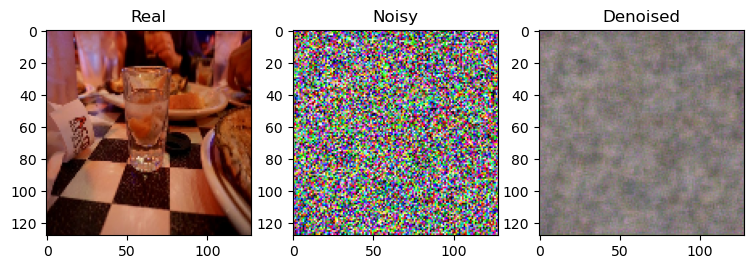

In [21]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
axs[0].imshow((image[0] + 1) / 2); axs[0].set_title("Real")
axs[1].imshow((noisy[0] + 1) / 2); axs[1].set_title("Noisy")
axs[2].imshow(((noisy - pred)[0] + 1) / 2); axs[2].set_title("Denoised")
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5486515..2.3557172].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6836591..2.4439387].


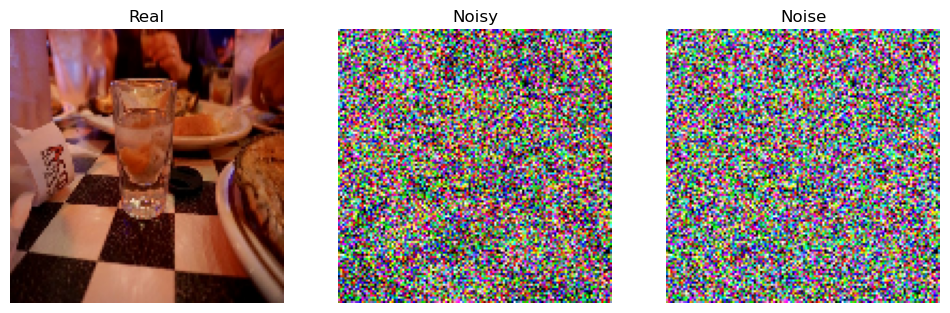

In [22]:
x0 = preprocess_image("data/photos/vkr8T0scuJmGVvN2HJelEA.jpg")[None]
t = tf.constant([500])
noise = tf.random.normal(tf.shape(x0))
noisy = scheduler.add_noise(x0, t, noise)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Real")
plt.imshow(((x0[0] + 1) / 2).numpy())
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Noisy")
plt.imshow(((noisy[0] + 1) / 2).numpy())
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Noise")
plt.imshow(((noise[0] + 1) / 2).numpy())
plt.axis("off")
plt.show()


# First Epoch sample images

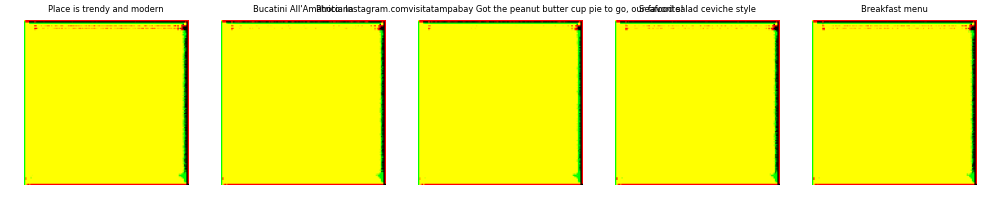

# Mid Epoch sample images

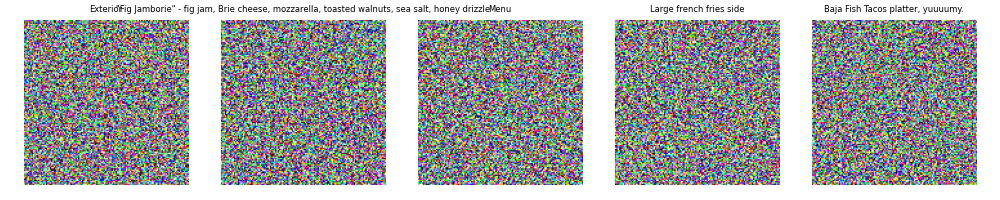

# Last Epoch sample images

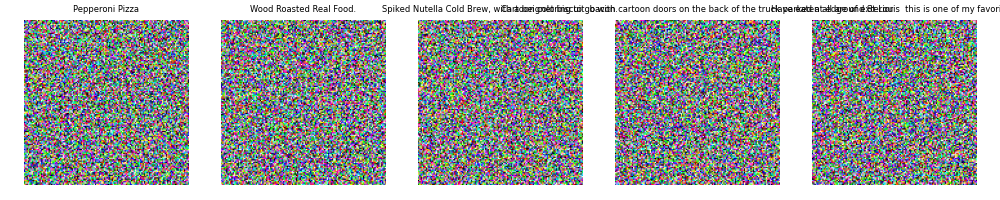

In [16]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4080 Laptop GPU, compute capability 8.9


In [17]:
mobilenet = tf.keras.applications.MobileNetV2(
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [18]:
def preprocess_for_mobilenet(images):
    images = tf.image.resize(images, [224, 224])
    return preprocess_input(images * 255.0)  # Scale from [0,1] → [0,255]


In [19]:
def get_activations(images, batch_size=16):
    images = preprocess_for_mobilenet(images)
    activations = []
    for i in range(0, images.shape[0], batch_size):
        batch = images[i:i+batch_size]
        with tf.device('/CPU:0'):  # or remove this if you want to try GPU again
            feats = mobilenet(batch, training=False)
        activations.append(feats)
    return tf.concat(activations, axis=0)


In [20]:
def calculate_fid(real_act, fake_act):
    # Flatten from [N, H, W, C] to [N, features]
    real_act = tf.reshape(real_act, [real_act.shape[0], -1]).numpy()
    fake_act = tf.reshape(fake_act, [fake_act.shape[0], -1]).numpy()

    mu1 = np.mean(real_act, axis=0)
    mu2 = np.mean(fake_act, axis=0)
    sigma1 = np.cov(real_act, rowvar=False)
    sigma2 = np.cov(fake_act, rowvar=False)

    diff = mu1 - mu2
    covmean, _ = sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)


In [21]:
from scipy.stats import entropy

def calculate_inception_score(features, splits=10):
    preds = tf.nn.softmax(features).numpy()
    split_scores = []
    N = preds.shape[0]
    for k in range(splits):
        part = preds[k * (N // splits): (k + 1) * (N // splits), :]
        py = np.mean(part, axis=0)
        scores = [entropy(p, py) for p in part]
        split_scores.append(np.mean(scores))
    return np.exp(np.mean(split_scores))

In [22]:
def generate_fake_images(unet, scheduler, prompts, image_size=128, timesteps=1000, batch_size=16):
    all_images = []
    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i + batch_size]
        bs = len(batch_prompts)
        t = tf.constant([timesteps - 1] * bs, dtype=tf.int32)

        x = tf.random.normal([bs, image_size, image_size, 3])
        text_emb = get_bert_embeddings_tf(tf.constant(batch_prompts))

        for t_val in reversed(range(timesteps)):
            t_tensor = tf.fill([bs], t_val)
            pred_noise = unet(x, t_tensor, text_emb)

            alpha = tf.convert_to_tensor(scheduler.alphas[t_val], dtype=tf.float32)
            alpha_bar = tf.convert_to_tensor(scheduler.alpha_bars[t_val], dtype=tf.float32)
            alpha_bar_prev = tf.convert_to_tensor(
                scheduler.alpha_bars[t_val - 1] if t_val > 0 else 1.0, dtype=tf.float32
            )
            beta = tf.convert_to_tensor(1.0 - alpha / alpha_bar_prev, dtype=tf.float32)

            noise = tf.random.normal(shape=x.shape) if t_val > 0 else 0.0

            x = (1.0 / tf.sqrt(alpha)) * (
                x - ((1 - alpha) / tf.sqrt(1 - alpha_bar)) * pred_noise
            ) + tf.sqrt(beta) * noise

        x = tf.clip_by_value((x + 1.0) / 2.0, 0.0, 1.0)  # Rescale to [0,1]
        all_images.append(x)

    return tf.concat(all_images, axis=0)


# Get real images from training dataset
def get_real_images(dataset, num_images=1000):
    real_images = []
    for batch in dataset:
        batch = (batch + 1.0) / 2.0 
        real_images.append(batch)
        if sum(x.shape[0] for x in real_images) >= num_images:
            break
    return tf.concat(real_images, axis=0)[:num_images]


In [23]:
# Sample prompts (can be from your training df)
prompts = df_photos["caption"].dropna().sample(30, random_state=42).tolist()

# Generate fake images
fake_imgs = generate_fake_images(unet, scheduler, prompts)

# Get real images (adjust dataset map if needed)
real_imgs = get_real_images(train_dataset.map(lambda img, _: img), num_images=30)

2025-04-01 12:15:55.174359: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.77GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-04-01 12:42:11.519940: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 161 of 10000
2025-04-01 12:42:21.553182: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 407 of 10000
2025-04-01 12:42:41.527113: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 776 of 10000
2025-04-01 12:42:51.492818: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 991 of 10000
2025-

In [24]:
act_fake = get_activations(fake_imgs)
act_real = get_activations(real_imgs)

fid_score = calculate_fid(act_real.numpy(), act_fake.numpy())
is_score = calculate_inception_score(fake_imgs)

print(f"Inception Score: {is_score:.4f}")
print(f"FID Score: {fid_score:.4f}")

2025-04-01 12:47:39.731217: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


ValueError: array must not contain infs or NaNs